In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Spark Session Topologies Benchmark

In [3]:
#Data import

#Raw files for boxplot, lineplot and barplot 
raw_thin = pd.read_csv("runs/raw_thin_session.csv")
raw_thin['Topology'] = 'Thin'

raw_balanced= pd.read_csv("runs/raw_balanced_session.csv")
raw_balanced['Topology'] = 'Balanced'

raw_fat = pd.read_csv("runs/raw_fat_session.csv")
raw_fat['Topology'] = 'Fat'

df_raw = pd.concat([raw_thin, raw_balanced, raw_fat], ignore_index=True)

## Boxplot

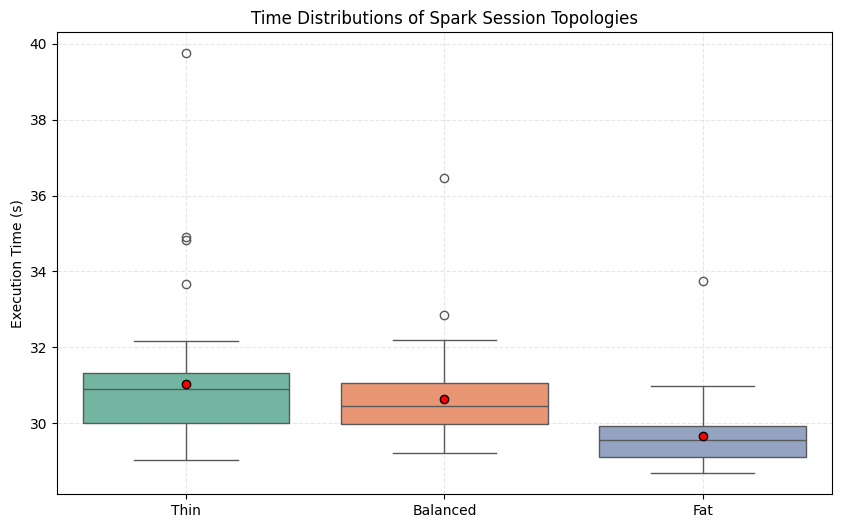

In [4]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Topology', y='execution_time', hue= 'Topology', legend=False, data= df_raw, palette='Set2',
            showmeans=True,
            meanprops={
            "marker": "o",                
            "markerfacecolor": "red",    
            "markeredgecolor": "black",   
            "markersize": "6"   
            })
plt.title('Time Distributions of Spark Session Topologies')
plt.xlabel('')
plt.ylabel('Execution Time (s)')
plt.grid(linestyle='--', alpha=0.3)
plt.show()

## Line Plot

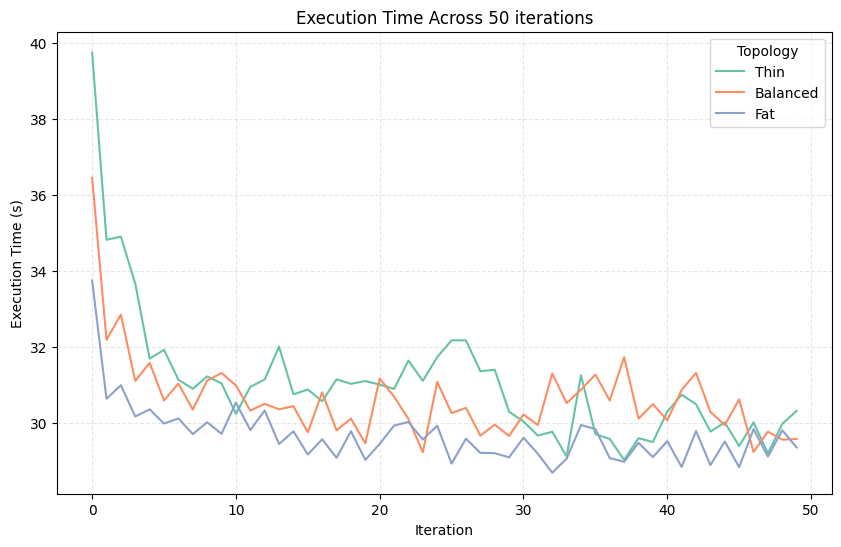

In [5]:
plt.figure(figsize=(10,6))
sns.lineplot(x='iteration_id', y='execution_time', hue='Topology', data=df_raw, legend=True, palette='Set2')
plt.title('Execution Time Across 50 iterations')
plt.xlabel('Iteration')
plt.ylabel('Execution Time (s)')
plt.grid(linestyle='--', alpha=0.3)
plt.show()

## Barplot

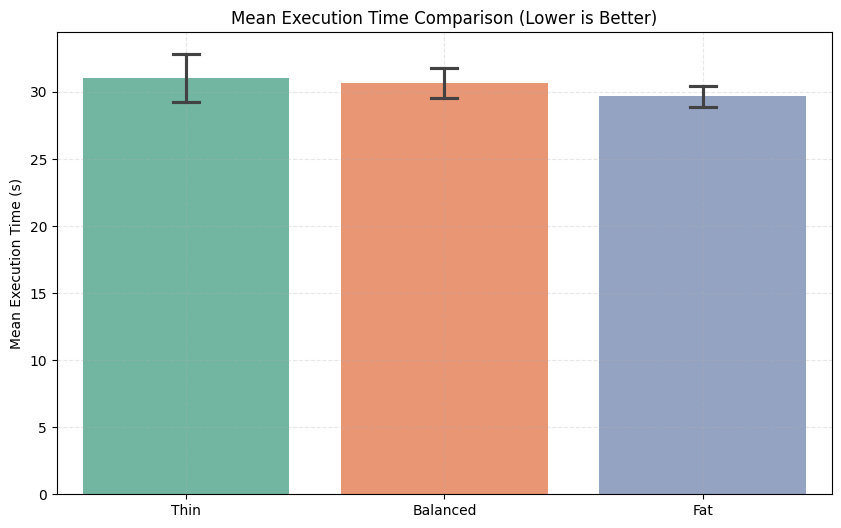

In [6]:
plt.figure(figsize=(10,6))
sns.barplot(x='Topology', y='execution_time', hue='Topology', legend=False, data=df_raw, palette='Set2', errorbar='sd', capsize=0.1)
plt.title('Mean Execution Time Comparison (Lower is Better)')
plt.xlabel('')
plt.ylabel('Mean Execution Time (s)')
plt.grid(linestyle='--', alpha=0.3)
plt.show()

# Partitions Benchmark

# Strong Scaling

In [7]:
#Data import

#Raw files for lineplot and boxplot
cores_4 = pd.read_csv("runs/stats_strong_scaling_4c.csv")
cores_4['PUs'] = '4 PUs'

cores_8 = pd.read_csv("runs/stats_strong_scaling_8c.csv")
cores_8['PUs'] = '8 PUs'

cores_12 = pd.read_csv("runs/stats_strong_scaling_12c.csv")
cores_12['PUs'] = '12 PUs'

cores_16 = pd.read_csv("runs/stats_strong_scaling_16c.csv")
cores_16['PUs'] = '16 PUs'

df_cores = pd.concat([cores_4, cores_8, cores_12, cores_16], ignore_index=True)

## Barplot

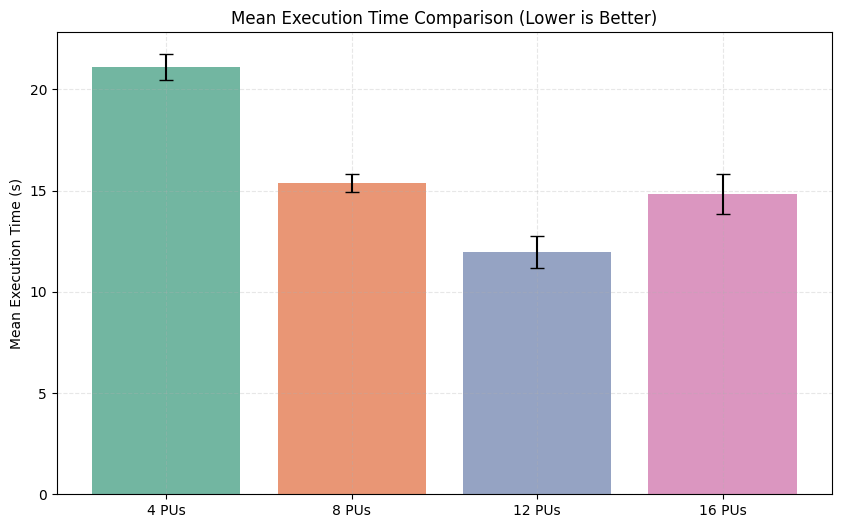

In [8]:
plt.figure(figsize=(10,6))
ax = sns.barplot(x='PUs', y='mean_time', hue='PUs', legend=False, data=df_cores, palette='Set2')

x_pos = [p.get_x() + p.get_width() / 2 for p in ax.patches]

plt.errorbar(
    x=x_pos, 
    y=df_cores['mean_time'], 
    yerr=df_cores['std_time'], 
    fmt='none',              
    c='black',               
    capsize=5,              
    elinewidth=1.5        
)

plt.title('Mean Execution Time Comparison (Lower is Better)')
plt.xlabel('')
plt.ylabel('Mean Execution Time (s)')
plt.grid(linestyle='--', alpha=0.3)
plt.show()

## Speed Up

/tmp/ipykernel_419851/3794702955.py:23: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x='PUs', y='ideal_speedup', data=df_plot, palette='Set2', marker = 'o', markersize = 8, label ='Ideal Speed Up', color=color_ideal)
/tmp/ipykernel_419851/3794702955.py:24: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x='PUs', y='real_speedup', data=df_plot, palette='Set2', marker = 'o', markersize = 8, label = 'Real Speed Up', color=color_real)


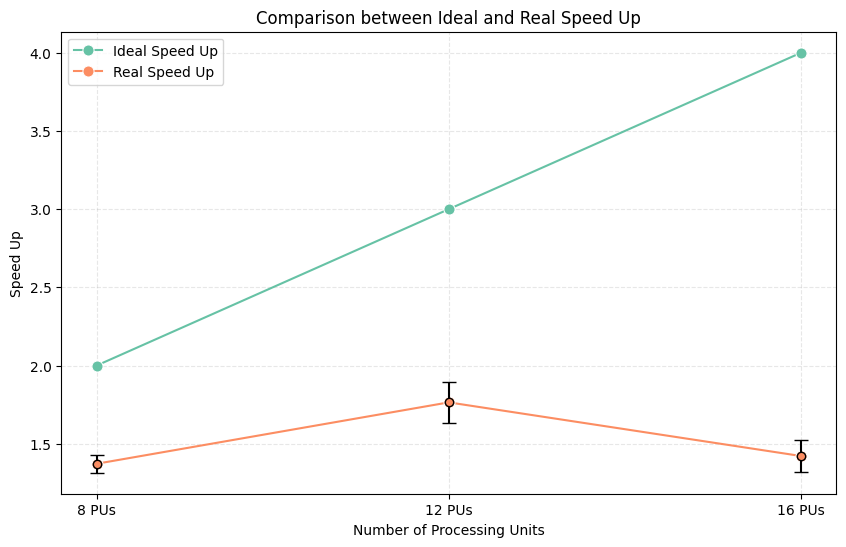

In [9]:
base_time = df_cores['mean_time'].iloc[0]
base_error = df_cores['std_time'].iloc[0]

df_cores['ideal_speedup'] = [1,2,3,4]
df_cores['real_speedup'] = base_time / df_cores['mean_time']


rel_error_base = base_error / base_time
rel_error_current = df_cores['std_time'] / df_cores['mean_time']
df_cores['speedup_error'] = df_cores['real_speedup'] * np.sqrt(rel_error_base**2 + rel_error_current**2)

df_cores['efficiency'] = (df_cores['real_speedup']/df_cores['ideal_speedup']) * 100
df_cores['efficiency_std'] = (df_cores['speedup_error']/df_cores['ideal_speedup']) * 100

df_plot = df_cores[df_cores['PUs'] != '4 PUs'].copy()

plt.figure(figsize=(10,6))

palette_set2 = sns.color_palette("Set2")
color_ideal = palette_set2[0]  
color_real = palette_set2[1]  

sns.lineplot(x='PUs', y='ideal_speedup', data=df_plot, palette='Set2', marker = 'o', markersize = 8, label ='Ideal Speed Up', color=color_ideal)
sns.lineplot(x='PUs', y='real_speedup', data=df_plot, palette='Set2', marker = 'o', markersize = 8, label = 'Real Speed Up', color=color_real)

plt.errorbar(
    x=df_plot['PUs'], 
    y=df_plot['real_speedup'], 
    yerr=df_plot['speedup_error'], 
    fmt='o', 
    #markersize=6, 
    markerfacecolor=color_real ,                  
    c='black', 
    capsize=5, 
    elinewidth=1.5
)
plt.title('Comparison between Ideal and Real Speed Up')
plt.xlabel('Number of Processing Units')
plt.ylabel('Speed Up')
plt.grid(linestyle ='--', alpha=0.3)
plt.show()

## Efficiency

/tmp/ipykernel_419851/1004087230.py:6: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x='PUs', y='efficiency', data=df_plot, palette='Set2', marker = 'o', markersize = 8, color=color_ideal)


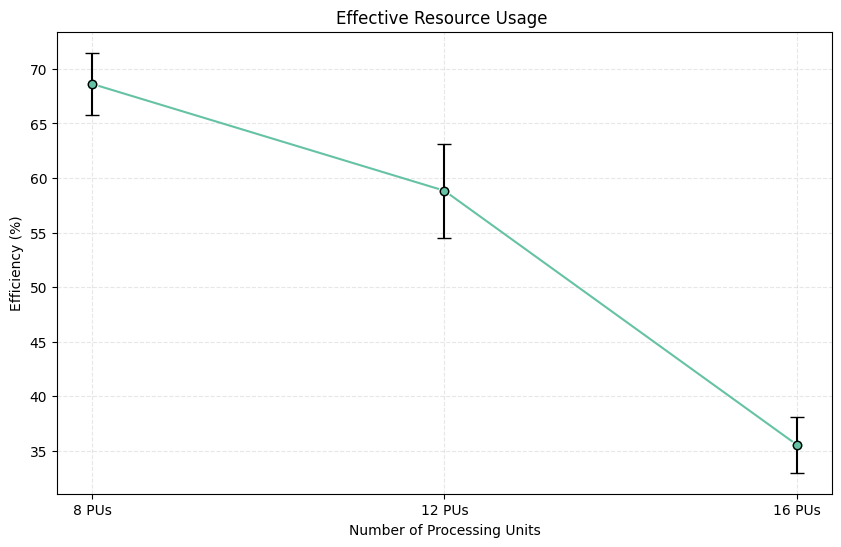

In [10]:
plt.figure(figsize=(10,6))

palette_set2 = sns.color_palette("Set2")
color_ideal = palette_set2[0]  

sns.lineplot(x='PUs', y='efficiency', data=df_plot, palette='Set2', marker = 'o', markersize = 8, color=color_ideal)

plt.errorbar(
    x=df_plot['PUs'], 
    y=df_plot['efficiency'], 
    yerr=df_plot['efficiency_std'], 
    fmt='o', 
    #markersize=6, 
    markerfacecolor=color_ideal ,                  
    c='black', 
    capsize=5, 
    elinewidth=1.5
)
plt.title('Effective Resource Usage ')
plt.xlabel('Number of Processing Units')
plt.ylabel(f'Efficiency (%)')
plt.grid(linestyle ='--', alpha=0.3)
plt.show()

# Weak Scaling